# AudioAngleNet evaluation on ROS1 test pairs

Load test samples from `data/pairs_ros1`, run the trained audio-only DOA model, and inspect predictions on the LiDAR bird's-eye view together with the label bbox.

In [9]:
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except NameError:
    pass

from collections import Counter
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib.patches import Polygon
from torch.utils.data import DataLoader

from dataloader.avped_audio_angle_dataloader import AVpedAudioAngleLoader
from network.audio_angle_net import AudioAngleNet

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True

## Configuration

Set `LOW_CUT_HZ` and `HIGH_CUT_HZ` to exactly the values used during training. Test loading never adds random background noise.

In [11]:
DATA_ROOT = 'data/pairs_ros1'
TEST_SPLIT = 'test'
OBJECT_FILTER = 'person'
AUDIO_CHANNELS = (1, 2, 3, 4)
FEATURE_TYPE = 'ipd'

# Select a checkpoint and its matching preprocessing configuration.
CHECKPOINT = Path('output_audio_angle_ros1_person_probability/model_best.pth')
LOW_CUT_HZ = 300.0
HIGH_CUT_HZ = 3000.0
FILTER_ORDER = 4
NUM_ANGLE_BINS = 360
TARGET_SIGMA_DEG = 5.0

DROPOUT_RATE = 0.4
FEATURE_DIM = 128
HIDDEN_DIM = 64
KERNEL_NUM = 8
BATCH_SIZE = 32
NUM_WORKERS = 0
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# Samples rendered in the visual inspection panel below.
VIS_SEQUENCE = 'person24'
VIS_STEMS = ['0001', '0002', '0003', '0004', '0005']

INPUT_CHANNELS = 1 + 2 * (len(AUDIO_CHANNELS) - 1) if FEATURE_TYPE == 'ipd' else len(AUDIO_CHANNELS)
print('device:', DEVICE)
print('checkpoint:', CHECKPOINT)
print('input channels:', INPUT_CHANNELS)
print('angle bins:', NUM_ANGLE_BINS, 'target sigma (deg):', TARGET_SIGMA_DEG)

device: cuda:0
checkpoint: output_audio_angle_ros1_person_probability/model_best.pth
input channels: 7
angle bins: 360 target sigma (deg): 5.0


In [12]:
test_data = AVpedAudioAngleLoader(
    root_path=DATA_ROOT,
    split=TEST_SPLIT,
    object_filter=OBJECT_FILTER,
    audio_channels=AUDIO_CHANNELS,
    feature_type=FEATURE_TYPE,
    # low_cut_hz=LOW_CUT_HZ,
    # high_cut_hz=HIGH_CUT_HZ,
    # filter_order=FILTER_ORDER,
    num_angle_bins=NUM_ANGLE_BINS,
    target_sigma_deg=TARGET_SIGMA_DEG,
    return_angle=True,
    return_metadata=True,
)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

model = AudioAngleNet(
    dropout_rate=DROPOUT_RATE,
    feature_dim=FEATURE_DIM,
    hidden_dim=HIDDEN_DIM,
    kernel_num=KERNEL_NUM,
    audio_channels=INPUT_CHANNELS,
    num_angle_bins=NUM_ANGLE_BINS,
).to(DEVICE)
model.load_state_dict(torch.load(CHECKPOINT, map_location=DEVICE, weights_only=True))
model.eval()

counts = Counter(sample['bag'] for sample in test_data.samples)
print('selected test sequences:', test_data.selected_sequences)
print('test samples:', len(test_data))
print('samples per sequence:', dict(counts))

selected test sequences: ['person24']
test samples: 451
samples per sequence: {'person24': 451}


In [13]:
def wrap_rad(angle):
    return np.arctan2(np.sin(angle), np.cos(angle))

def circular_error_deg(pred_rad, target_rad):
    return np.degrees(np.abs(wrap_rad(pred_rad - target_rad)))

records = []
with torch.no_grad():
    for spec, _, gt_angle, meta in test_loader:
        pred_probability = model(spec.to(DEVICE)).cpu().numpy()
        pred_bins = np.argmax(pred_probability, axis=1)
        pred_angle = pred_bins * (2.0 * np.pi / NUM_ANGLE_BINS)
        for index in range(len(pred_angle)):
            gt_rad = float(gt_angle[index])
            pred_rad = float(pred_angle[index])
            records.append({
                'sequence': meta['sequence'][index],
                'stem': meta['stem'][index],
                'gt_rad': gt_rad,
                'pred_rad': pred_rad,
                'gt_deg': float(np.degrees(gt_rad) % 360.0),
                'pred_deg': float(np.degrees(pred_rad) % 360.0),
                'error_deg': float(circular_error_deg(pred_rad, gt_rad)),
                'confidence': float(pred_probability[index].max()),
                'probability': pred_probability[index],
                'label': meta['label'][index],
                'lidar': meta['lidar'][index],
            })

results = pd.DataFrame(records).sort_values(['sequence', 'stem']).reset_index(drop=True)
summary = results.groupby('sequence').agg(frames=('stem', 'count'), mae_deg=('error_deg', 'mean'), median_deg=('error_deg', 'median'), max_deg=('error_deg', 'max'))
summary.loc['ALL'] = [len(results), results['error_deg'].mean(), results['error_deg'].median(), results['error_deg'].max()]
summary.round(3)

,frames,mae_deg,median_deg,max_deg
sequence,,,,
person24,451.0,12.072,9.245,131.0
ALL,451.0,12.072,9.245,131.0


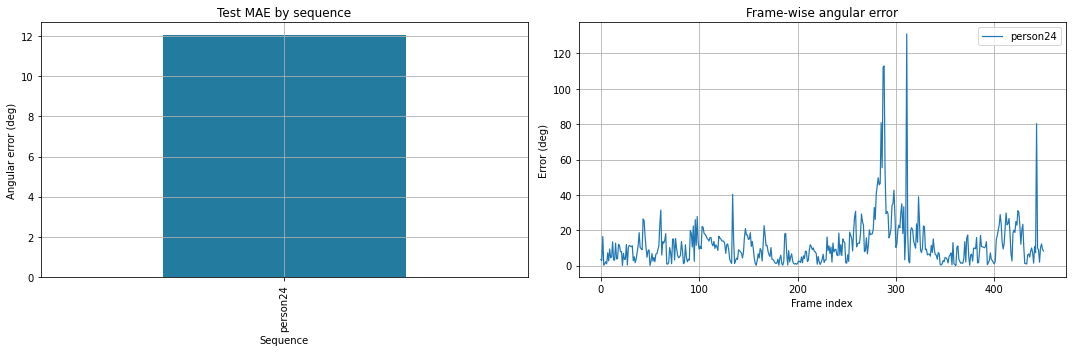

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sequence_summary = summary.drop(index='ALL')
sequence_summary['mae_deg'].plot.bar(ax=axes[0], color='#247ba0')
axes[0].set_title('Test MAE by sequence')
axes[0].set_ylabel('Angular error (deg)')
axes[0].set_xlabel('Sequence')

for sequence, group in results.groupby('sequence'):
    axes[1].plot(np.arange(len(group)), group['error_deg'].to_numpy(), label=sequence, linewidth=1.2)
axes[1].set_title('Frame-wise angular error')
axes[1].set_xlabel('Frame index')
axes[1].set_ylabel('Error (deg)')
axes[1].legend()
fig.tight_layout()
plt.show()

## Visualize specified test samples

Red rectangle: the LiDAR bbox label used as DOA ground truth. Cyan ray: GT DOA. Orange ray: probability argmax. The probability panel shows the full network output distribution.

In [15]:
def load_labelcloud_box(path):
    lines = [line for line in Path(path).read_text().splitlines() if line.strip()]
    if len(lines) != 1:
        return None
    fields = lines[0].split()
    h, w, l = map(float, fields[8:11])
    x, y, z, yaw = map(float, fields[11:15])
    return np.asarray([x, y, z, l, w, h, yaw], dtype=np.float32)

def bbox_bev_corners(box):
    x, y, _, dx, dy, _, yaw = box
    corners = np.asarray([[dx / 2, dy / 2], [dx / 2, -dy / 2], [-dx / 2, -dy / 2], [-dx / 2, dy / 2]])
    rotation = np.asarray([[np.cos(yaw), -np.sin(yaw)], [np.sin(yaw), np.cos(yaw)]])
    return corners @ rotation.T + np.asarray([x, y])

def draw_doa_ray(ax, angle, color, label, length=4.7):
    ax.plot([0.0, length * np.cos(angle)], [0.0, length * np.sin(angle)], color=color, linewidth=2.2, label=label)

def visualize_prediction(row, ax, axis_limit=5.3):
    points = np.fromfile(row['lidar'], dtype=np.float32).reshape(-1, 4)
    box = load_labelcloud_box(row['label'])
    scatter = ax.scatter(points[:, 0], points[:, 1], c=points[:, 2], s=0.35, cmap='viridis', linewidths=0)
    if box is not None:
        ax.add_patch(Polygon(bbox_bev_corners(box), closed=True, fill=False, edgecolor='red', linewidth=2, label='bbox'))
    draw_doa_ray(ax, row['gt_rad'], 'cyan', 'GT DOA')
    draw_doa_ray(ax, row['pred_rad'], 'orange', 'Prediction')
    ax.scatter([0], [0], color='white', edgecolor='black', s=35, zorder=5)
    ax.set_xlim(-axis_limit, axis_limit)
    ax.set_ylim(-axis_limit, axis_limit)
    ax.set_aspect('equal', adjustable='box')
    ax.set_title(f"{row['sequence']} / {row['stem']}\nGT {row['gt_deg']:.1f} deg | Pred {row['pred_deg']:.1f} deg | Err {row['error_deg']:.1f} deg")
    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')
    return scatter

def visualize_probability(row, ax):
    angles_deg = np.arange(NUM_ANGLE_BINS) * (360.0 / NUM_ANGLE_BINS)
    probability = np.asarray(row['probability'])
    ax.fill_between(angles_deg, probability, color='#2a9d8f', alpha=0.2)
    ax.plot(angles_deg, probability, color='#176b63', linewidth=1.6, label='Probability')
    ax.axvline(row['gt_deg'], color='cyan', linewidth=2, label='GT DOA')
    ax.axvline(row['pred_deg'], color='orange', linewidth=2, label='Argmax')
    ax.set_xlim(0, 360)
    ax.set_xticks(np.arange(0, 361, 60))
    ax.set_ylim(bottom=0)
    ax.set_title(f"Output probability | peak={row['confidence']:.3f}")
    ax.set_xlabel('Azimuth (deg)')
    ax.set_ylabel('Probability')
    ax.legend(loc='upper right', fontsize=8)

selected = results[(results['sequence'] == VIS_SEQUENCE) & (results['stem'].isin(VIS_STEMS))]
if selected.empty:
    raise ValueError(f'No samples selected for {VIS_SEQUENCE}: {VIS_STEMS}')
fig, axes = plt.subplots(len(selected), 2, figsize=(13, 5 * len(selected)), squeeze=False)
for row_index, (_, row) in enumerate(selected.iterrows()):
    scatter = visualize_prediction(row, axes[row_index, 0])
    visualize_probability(row, axes[row_index, 1])
fig.colorbar(scatter, ax=axes[:, 0].tolist(), fraction=0.025, pad=0.02, label='z (m)')
fig.tight_layout()
plt.show()

ValueError: No samples selected for person24: ['0001', '0002', '0003', '0004', '0005']

## Inspect worst predictions

/tmp/ipykernel_1110976/3853886996.py:8: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


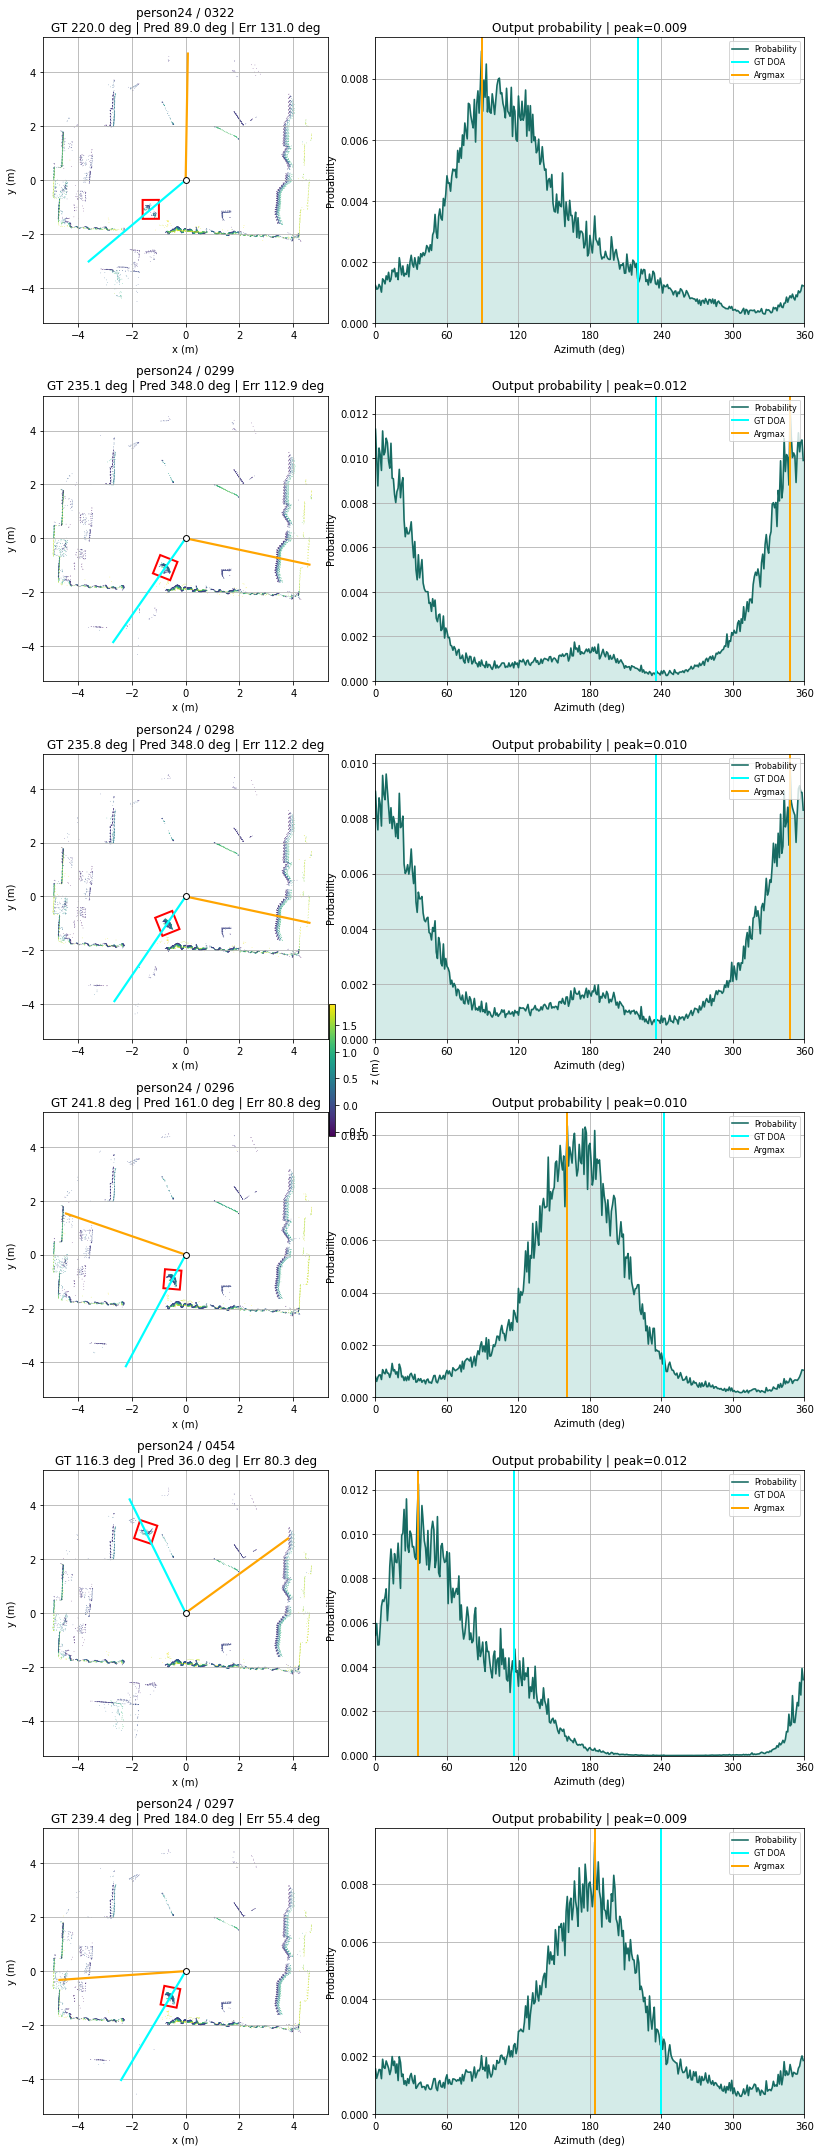

,sequence,stem,gt_deg,pred_deg,error_deg
311,person24,0322,220.000,89.0,131.000
288,person24,0299,235.098,348.0,112.902
287,person24,0298,235.762,348.0,112.238
285,person24,0296,241.815,161.0,80.815
443,person24,0454,116.260,36.0,80.260
286,person24,0297,239.354,184.0,55.354


In [16]:
TOP_K = 6
worst = results.sort_values('error_deg', ascending=False).head(TOP_K)
fig, axes = plt.subplots(TOP_K, 2, figsize=(13, 5 * TOP_K), squeeze=False)
for row_index, (_, row) in enumerate(worst.iterrows()):
    scatter = visualize_prediction(row, axes[row_index, 0])
    visualize_probability(row, axes[row_index, 1])
fig.colorbar(scatter, ax=axes[:, 0].tolist(), fraction=0.02, pad=0.02, label='z (m)')
fig.tight_layout()
plt.show()
worst[['sequence', 'stem', 'gt_deg', 'pred_deg', 'error_deg']].round(3)

In [17]:
# Export visualizations for every evaluated sample.
EXPORT_DIR = Path('data/pairs_ros1/audio_angle_probability_visualizations')
EXPORT_DPI = 130
EXPORT_AXIS_LIMIT = 5.3
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

export_records = []
for index, row in results.iterrows():
    sequence_dir = EXPORT_DIR / row['sequence']
    sequence_dir.mkdir(parents=True, exist_ok=True)
    output_path = sequence_dir / f"{row['stem']}.png"

    fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.4), gridspec_kw={'width_ratios': [1.02, 1]})
    scatter = visualize_prediction(row, axes[0], axis_limit=EXPORT_AXIS_LIMIT)
    handles, labels = axes[0].get_legend_handles_labels()
    axes[0].legend(handles, labels, loc='upper right', fontsize=8)
    visualize_probability(row, axes[1])
    fig.colorbar(scatter, ax=axes[0], fraction=0.045, pad=0.03, label='z (m)')
    fig.tight_layout()
    fig.savefig(output_path, dpi=EXPORT_DPI, bbox_inches='tight')
    plt.close(fig)

    export_records.append({
        'sequence': row['sequence'],
        'stem': row['stem'],
        'gt_deg': row['gt_deg'],
        'pred_deg': row['pred_deg'],
        'error_deg': row['error_deg'],
        'confidence': row['confidence'],
        'visualization': str(output_path),
    })

export_manifest = pd.DataFrame(export_records).sort_values('error_deg', ascending=False)
manifest_path = EXPORT_DIR / 'manifest.csv'
export_manifest.to_csv(manifest_path, index=False)
print(f'Exported {len(export_manifest)} visualizations to {EXPORT_DIR}')
print(f'Manifest: {manifest_path}')
export_manifest.head(10).round(3)

Exported 451 visualizations to data/pairs_ros1/audio_angle_probability_visualizations
Manifest: data/pairs_ros1/audio_angle_probability_visualizations/manifest.csv


,sequence,stem,gt_deg,pred_deg,error_deg,confidence,visualization
311,person24,0322,220.000,89.0,131.000,0.009,data/pairs_ros1/audio_angle_probability_visual...
288,person24,0299,235.098,348.0,112.902,0.012,data/pairs_ros1/audio_angle_probability_visual...
287,person24,0298,235.762,348.0,112.238,0.010,data/pairs_ros1/audio_angle_probability_visual...
285,person24,0296,241.815,161.0,80.815,0.010,data/pairs_ros1/audio_angle_probability_visual...
443,person24,0454,116.260,36.0,80.260,0.012,data/pairs_ros1/audio_angle_probability_visual...
286,person24,0297,239.354,184.0,55.354,0.009,data/pairs_ros1/audio_angle_probability_visual...
289,person24,0300,235.774,184.0,51.774,0.011,data/pairs_ros1/audio_angle_probability_visual...
282,person24,0293,248.714,199.0,49.714,0.015,data/pairs_ros1/audio_angle_probability_visual...
284,person24,0295,242.480,196.0,46.480,0.015,data/pairs_ros1/audio_angle_probability_visual...
283,person24,0294,245.716,200.0,45.716,0.014,data/pairs_ros1/audio_angle_probability_visual...
